In this notebook, we implement **cascased multi-label classification using semi-supervised approach**. The model is trained using the SELT Responses 2024 dataset. The pre-trained model used here is RoBERTa, but it can also be replaced with DeBERTa or other pre-trained models by updating the variable `MODEL_NAME` below.

# Setting Seeds

Here, we begin by setting the random seeds to ensure reproducibility across different runs.

In [1]:
import random
from transformers import set_seed
import os

import pandas as pd
import numpy as np
import warnings
import ast
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, multilabel_confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from datasets import Dataset

import warnings
warnings.filterwarnings('ignore') 

def set_all_seeds(seed=42):
    """Set seeds for reproducible results"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

# Set all seeds
set_all_seeds(42)

# Set device

We also set the device to use the GPU if available, for more efficient execution.

In [2]:
if torch.backends.mps.is_available(): 
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


# Load Data and Data Preparation

After setting up the environment configuration, we import the data into the notebook and perform data preparation. Here, we use the **SELT Responses 2024 and synthetic data** to train the model. The details of each imported dataset are as follows:
1. `survey_df`: 1,000 samples from SELT Responses 2024 that are manually labeled for training.
2. `survey_test_df`: 100 samples from SELT Responses 2024 that are separated from training and used for final testing.
3. `survey_unlabeled_df`: Remaining samples from the dataset without labels, used for semi-supervised training.
4. `synthetic_df`: Training data generated using ClaudeAI.

These datasets can be replaced with other files, as long as they maintain the same characteristics, column names, and data format.

For the data preparation, we perform the following tasks to clean the dataset:
1. Lowercasing and remove non-alphanumeric characters.
2. Remove noisy responses (fewer than 10 characters).
2. Sort and encode the labels.
3. Split training dataset into training and validation sets.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from collections import Counter
import nlpaug.augmenter.word as naw
from collections import defaultdict
import random
import re

### 1. Import clean survey data
survey_df = pd.read_excel('SELT_sampled_data.xlsx')
survey_test_df = pd.read_excel('SELT_testing_data.xlsx')
survey_unlabelled_df = pd.read_excel('SELT_remaining_data.xlsx')
synthetic_df = pd.read_excel('synthetic_data_mixed_labels.xlsx')

# Adjust columns for consistency
survey_df = survey_df.rename(columns={
    "pred_appropriateness": "inappropriate_appropriate",
    "pred_categories": "all_labels"
})

survey_test_df = survey_test_df.rename(columns={
    "pred_appropriateness": "inappropriate_appropriate",
    "pred_categories": "all_labels"
})

survey_unlabelled_df = survey_unlabelled_df.rename(columns={
    "pred_appropriateness": "inappropriate_appropriate",
    "pred_categories": "all_labels"
})

survey_df = survey_df[['course_name', 'question', 'student_response', 'inappropriate_appropriate', 'all_labels']].copy()
survey_test_df = survey_test_df[['course_name', 'question', 'student_response', 'inappropriate_appropriate', 'all_labels']].copy()
survey_unlabelled_df = survey_unlabelled_df[['course_name', 'question', 'student_response', 'inappropriate_appropriate', 'all_labels']].copy()
synthetic_df = synthetic_df[['course_name', 'question', 'student_response', 'inappropriate_appropriate', 'all_labels']].copy()

### 2. Data Preparation
# a. Student response preprocessing
def text_preprocessing(text):
    # Remove regex (any non-alphanumeric characters) and keeping only letters, numbers, and spaces using regex
    text = re.sub(r'[^a-zA-Z0-9 ]', '', text)

    # Lowercasing
    text = text.lower()

    return text

survey_df['student_response'] = survey_df['student_response'].apply(lambda x: text_preprocessing(x))
synthetic_df['student_response'] = synthetic_df['student_response'].apply(lambda x: text_preprocessing(x))
survey_unlabelled_df['student_response'] = survey_unlabelled_df['student_response'].apply(lambda x: text_preprocessing(x))
survey_test_df['student_response'] = survey_test_df['student_response'].apply(lambda x: text_preprocessing(x))

# b. Remove noisy text
filtered_df = survey_df[survey_df['student_response'].str.len()>10].copy()
survey_unlabelled_df = survey_unlabelled_df[survey_unlabelled_df['student_response'].str.len()>10].copy()
synthetic_df = synthetic_df[synthetic_df['student_response'].str.len()>10].copy()

# c. Sort and clean the label
filtered_df['all_labels'] = filtered_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)
synthetic_df['all_labels'] = synthetic_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)
survey_test_df['all_labels'] = survey_test_df['all_labels'].apply(lambda x: sorted(x) if isinstance(x, list) else x)

def clean_and_sort_labels(x):
    # Convert string labels to list
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try:
                x_list = ast.literal_eval(x)
            except:
                x_list = x.strip("[]").split(",")
        else:
            x_list = x.split(",")
    elif isinstance(x, list):
        x_list = x
    else:
        return []

    # Clean, deduplicate, and sort
    cleaned = {str(item).strip().strip("[]\"'") for item in x_list if str(item).strip().strip("[]\"'")}
    return sorted(cleaned, key=str.lower)

filtered_df['all_labels'] = filtered_df['all_labels'].apply(clean_and_sort_labels)
synthetic_df['all_labels'] = synthetic_df['all_labels'].apply(clean_and_sort_labels)
survey_test_df['all_labels'] = survey_test_df['all_labels'].apply(clean_and_sort_labels)

# Combine the manually labelled SELT survey with the synthetic data
labelled_df = pd.concat([filtered_df, synthetic_df], ignore_index=True)

### 3. Encode the labels
# Encode multi-label
mlb = MultiLabelBinarizer(classes=["course materials & structure", "teaching & delivery", "assignment & quiz"])

y_multi = mlb.fit_transform(labelled_df["all_labels"])
y_multi_test = mlb.transform(survey_test_df["all_labels"])
y_multi_unlabelled = mlb.transform(survey_unlabelled_df["all_labels"])

# Encode binary-label
app_map = {"inappropriate": 0, "appropriate": 1}
labelled_df['inappropriate_appropriate'] = labelled_df['inappropriate_appropriate'].map(app_map)
survey_test_df['inappropriate_appropriate'] = survey_test_df['inappropriate_appropriate'].map(app_map)
survey_unlabelled_df['inappropriate_appropriate'] = survey_unlabelled_df['inappropriate_appropriate'].map(app_map)
y_binary_train_val = labelled_df['inappropriate_appropriate'].copy()

### 4. Split The Data
# Combine both label types into a single multi-label matrix
combined_labels = np.column_stack([y_binary_train_val.values.reshape(-1, 1), y_multi])
X = labelled_df['student_response'].copy()

# Split 1: Split out test
X_test = survey_test_df['student_response'].copy()
y_binary_test = survey_test_df['inappropriate_appropriate'].copy()

# Split 2: Split 8% of train_val as validation
X_train_val = labelled_df['student_response'].copy()
y_binary_train_val = y_binary_train_val.copy()
y_multi_train_val = y_multi.copy()

combined_labels = np.column_stack([y_binary_train_val.values.reshape(-1, 1), y_multi_train_val])
msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.08, random_state=42)
train_idx, val_idx = next(msss_val.split(X_train_val, combined_labels))

X_train, X_val = X_train_val.iloc[train_idx], X_train_val.iloc[val_idx]
y_binary_train, y_binary_val = y_binary_train_val.iloc[train_idx], y_binary_train_val.iloc[val_idx]
y_multi_train, y_multi_val = y_multi_train_val[train_idx], y_multi_train_val[val_idx]

# Create DataFrames
train_df = pd.DataFrame({"student_response": X_train.values, "labels_binary": y_binary_train})
val_df = pd.DataFrame({"student_response": X_val.values, "labels_binary": y_binary_val})
test_df = pd.DataFrame({"student_response": X_test.values, "labels_binary": y_binary_test})
unlabelled_df = pd.DataFrame({"student_response": survey_unlabelled_df['student_response'].values, "labels_binary": survey_unlabelled_df['inappropriate_appropriate'].values})

train_df["multi_labels"] = [list(arr) for arr in y_multi_train]
val_df["multi_labels"]   = [list(arr) for arr in y_multi_val]
test_df["multi_labels"]  = [list(arr) for arr in y_multi_test]
unlabelled_df["multi_labels"] = [list(arr) for arr in y_multi_unlabelled]


### 5. Check the processing result
# Train label distributions
print("Train set shape:", train_df.shape)
print(f'Train proportion label 1: {Counter(y_binary_train)}')
y_multi_train_str = ['_'.join(map(str, row)) for row in y_multi_train]
print(f'Train proportion label 2:\n{pd.Series(y_multi_train_str).value_counts()}\n')

# Validation label distributions
print("Validation set shape:", val_df.shape)
print(f'Validation proportion label 1: {Counter(y_binary_val)}')
y_multi_val_str = ['_'.join(map(str, row)) for row in y_multi_val]
print(f'Validation proportion label 2:\n{pd.Series(y_multi_val_str).value_counts()}\n')

# Test label distributions
print("Test set shape:", test_df.shape)
print(f'Test proportion label 1: {Counter(y_binary_test)}')
y_multi_test_str = ['_'.join(map(str, row)) for row in y_multi_test]
print(f'Test proportion label 2:\n{pd.Series(y_multi_test_str).value_counts()}\n')


Train set shape: (1491, 3)
Train proportion label 1: Counter({1: 1231, 0: 260})
Train proportion label 2:
0_1_0    326
1_0_0    284
1_1_0    250
0_0_1    232
1_1_1    216
0_1_1     96
1_0_1     87
Name: count, dtype: int64

Validation set shape: (129, 3)
Validation proportion label 1: Counter({1: 107, 0: 22})
Validation proportion label 2:
0_1_0    26
1_1_0    24
1_0_0    24
0_0_1    19
1_1_1    17
0_1_1    11
1_0_1     8
Name: count, dtype: int64

Test set shape: (100, 3)
Test proportion label 1: Counter({1: 70, 0: 30})
Test proportion label 2:
0_1_0    22
1_0_0    20
0_1_1    14
1_1_0    13
1_0_1    11
0_0_1    10
1_1_1    10
Name: count, dtype: int64



# Model Setup

Here, we define the model architecture to perform semi-supervised training for two classification tasks: appropriateness and categorization. The appropriateness task will be performed as a **single-label classification**, while the categorization task will be performed as a **multi-label classification** for each response. 

As mentioned earlier, we are currently using RoBERTa in this notebook, but it can be changed by updating the `MODEL_NAME` variable below.

In [25]:
from datasets import Sequence, Value
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
import torch.nn as nn

### 1. Load models
MODEL_NAME = "roberta-base"

### 2. Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

### 3. Define model Architecture
# Classifier 1: Multi-label for category prediction
multi_label_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=3,
    problem_type="multi_label_classification")

multi_label_model = multi_label_model.to(device)

# Classifier 2: Binary-label for appropriateness prediction
class CascadedBinaryModel(nn.Module):
    def __init__(self, base_model_name, num_multilabel_classes=3):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(base_model_name)
        hidden_size = self.roberta.config.hidden_size
        
        # Classifier that combines text features with multi-label predictions
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + num_multilabel_classes, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, 1)
        )
        
    def forward(self, input_ids, attention_mask, multilabel_preds=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        
        # Concatenate text features with multi-label predictions
        if multilabel_preds is not None:
            combined_features = torch.cat([pooled_output, multilabel_preds], dim=1)
        else:
            # During inference without multi-label predictions
            combined_features = torch.cat([pooled_output, torch.zeros(pooled_output.size(0), 3).to(pooled_output.device)], dim=1)
            
        logits = self.classifier(combined_features)
        return type('ModelOutput', (), {'logits': logits})()

binary_model = CascadedBinaryModel(MODEL_NAME).to(device)

### 4. Freeze transformer layers
def freeze_lower_layers(model, num_layers_to_freeze=8):

    for param in model.roberta.embeddings.parameters():
        param.requires_grad = False
    
    for i in range(num_layers_to_freeze):
        for param in model.roberta.encoder.layer[i].parameters():
            param.requires_grad = False

    print(f"Frozen first {num_layers_to_freeze} layers and embeddings")
    
    # Print number of trainable parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Frozen parameters: {total_params - trainable_params:,}")

freeze_lower_layers(multi_label_model, num_layers_to_freeze=8)
freeze_lower_layers(binary_model, num_layers_to_freeze=10)

### 5. Create Hugging Face Datasets and Tokenise (updated for both label types)
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)
unlabeled_dataset = Dataset.from_pandas(unlabelled_df)

def tokenize(batch):
    texts = [str(x) for x in batch["student_response"]]
    return tokenizer(texts, 
                     padding="max_length", 
                     truncation=True, 
                     max_length=256)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)
unlabeled_dataset = unlabeled_dataset.map(tokenize, batched=True)

# Remove unwanted columns
keep_cols = ["input_ids", "attention_mask", "multi_labels", "labels_binary", "student_response"]

train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])
test_dataset = test_dataset.remove_columns([c for c in test_dataset.column_names if c not in keep_cols])
unlabeled_dataset = unlabeled_dataset.remove_columns([c for c in test_dataset.column_names if c not in keep_cols])

# Cast labels
train_dataset = train_dataset.cast_column("multi_labels", Sequence(Value("float32")))
val_dataset = val_dataset.cast_column("multi_labels", Sequence(Value("float32")))
test_dataset = test_dataset.cast_column("multi_labels", Sequence(Value("float32")))

train_dataset = train_dataset.cast_column("labels_binary", Value("int64"))
val_dataset = val_dataset.cast_column("labels_binary", Value("int64"))
test_dataset = test_dataset.cast_column("labels_binary", Value("int64"))

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "multi_labels", "labels_binary"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "multi_labels", "labels_binary"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "multi_labels", "labels_binary"])

### 6. Evaluation Metrics 
def compute_metrics_multilabel(predictions, labels, tune=False):
    """Same as your compute_metrics_multilabel but for tensors"""
    probs = torch.sigmoid(predictions).cpu().numpy()
    y_true = labels.cpu().numpy()
    
    if tune:
        # Tune thresholds per label
        best_thresholds = tune_thresholds(y_true, probs)
        y_pred = np.zeros_like(y_true)
        for i, t in enumerate(best_thresholds):
            y_pred[:, i] = (probs[:, i] >= t).astype(int)
    else:
        # Default threshold = 0.5
        y_pred = (probs >= 0.5).astype(int)
    
    # Metrics
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    subset_accuracy = (y_pred == y_true).all(axis=1).mean()
    hamming_loss = (y_pred != y_true).mean()
    
    return {
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "subset_accuracy": subset_accuracy,
        "hamming_loss": hamming_loss
    }

def tune_thresholds(y_true, probs):
    best_thresholds = []
    for i in range(probs.shape[1]):
        best_f1, best_t = 0, 0.5
        for t in np.linspace(0.1, 0.9, 17):  # search 0.1 → 0.9
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
    return np.array(best_thresholds)

def compute_metrics_binary(predictions, labels):
    """Metrics for binary classification"""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()
    
    predictions = predictions.cpu().numpy().flatten()
    labels = labels.cpu().numpy().flatten()
    
    
    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='binary', zero_division=0)
    recall = recall_score(labels, predictions, average='binary', zero_division=0)
    f1 = f1_score(labels, predictions, average='binary', zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "specificity": specificity,
        "sensitivity": sensitivity
    }

### 7. Class Weighting 
# Convert multi-label column to 2D array
multi_labels_array = np.array(train_df.multi_labels.tolist())

# Calculate class weights for multi-label
def calculate_multilabel_class_weights(labels_array):
    """Calculate positive weights for each class in multi-label setting"""
    pos_weights = []
    n_samples = len(labels_array)
    
    for i in range(labels_array.shape[1]):  
        pos_count = labels_array[:, i].sum()
        neg_count = n_samples - pos_count
        
        if pos_count > 0:
            pos_weight = neg_count / pos_count
        else:
            pos_weight = 1.0
            
        pos_weights.append(pos_weight)
    
    return torch.FloatTensor(pos_weights).to(device)

# Calculate class weights for binary
def calculate_binary_class_weights(labels_array):
    """Calculate class weights for binary classification"""
    pos_count = labels_array.sum()
    neg_count = len(labels_array) - pos_count
    
    if pos_count > 0:
        pos_weight = neg_count / pos_count
    else:
        pos_weight = 1.0
        
    return torch.FloatTensor([pos_weight]).to(device)

# Calculate class weights for both models
multi_class_weights = calculate_multilabel_class_weights(multi_labels_array)
binary_class_weights = calculate_binary_class_weights(train_df.labels_binary.values)

print("\nMulti-label class weights (pos_weight):", multi_class_weights)
print("Binary class weights (pos_weight):", binary_class_weights)

# Print label distributions
labels_names = ["assignment & quiz", "course materials & structure", "teaching & delivery"]

print("\nMulti-label distribution in training data:")

for i, name in enumerate(labels_names):
    
    count = multi_labels_array[:, i].sum()
    percentage = (count / len(train_df.multi_labels)) * 100
    print(f"  {name}: {count} samples ({percentage:.1f}%)")

print(f"\nBinary label distribution:")
binary_counts = train_df.labels_binary.value_counts()
print(f"  Class 0: {binary_counts.get(0, 0)} samples")
print(f"  Class 1: {binary_counts.get(1, 0)} samples")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Frozen first 8 layers and embeddings
Total parameters: 124,647,939
Trainable parameters: 28,944,387
Frozen parameters: 95,703,552
Frozen first 10 layers and embeddings
Total parameters: 124,942,465
Trainable parameters: 15,063,169
Frozen parameters: 109,879,296


Map:   0%|          | 0/1491 [00:00<?, ? examples/s]

Map:   0%|          | 0/129 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

...

Casting the dataset:   0%|          | 0/104 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1491 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/129 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/104 [00:00<?, ? examples/s]


Multi-label class weights (pos_weight): tensor([0.7814, 0.6791, 1.3629], device='mps:0')
Binary class weights (pos_weight): tensor([0.2112], device='mps:0')

Multi-label distribution in training data:
  assignment & quiz: 837 samples (56.1%)
  course materials & structure: 888 samples (59.6%)
  teaching & delivery: 631 samples (42.3%)

Binary label distribution:
  Class 0: 260 samples
  Class 1: 1231 samples


## Semi-supervised setup (additional)

To maintain a similar structure to the supervised training that uses only synthetic data, the model architecture above is exactly the same with the other notebooks. However, we make slight modifications to adapt the architecture for semi-supervised training, allowing it to incorporate some of the unlabeled data during training.

In [17]:
from datasets import Dataset
from tqdm import tqdm


### 1. Function to prepare unlabeled dataset for pseudo-labeling
def prepare_unlabeled_dataset(unlabeled_df, tokenizer, max_length=256):
    
    # Create dataset from dataframe
    unlabeled_dataset = Dataset.from_pandas(unlabeled_df)
    
    # Tokenize
    def tokenize(batch):
        texts = [str(x) for x in batch["student_response"]]
        return tokenizer(texts, 
                         padding="max_length", 
                         truncation=True, 
                         max_length=max_length)
    
    unlabeled_dataset = unlabeled_dataset.map(tokenize, batched=True)
    
    # Keep only necessary columns
    keep_cols = ["input_ids", "attention_mask", "student_response"]
    unlabeled_dataset = unlabeled_dataset.remove_columns([c for c in unlabeled_dataset.column_names if c not in keep_cols])
    
    # Set format for PyTorch
    unlabeled_dataset.set_format("torch", columns=["input_ids", "attention_mask"], output_all_columns=True)
    
    return unlabeled_dataset

### 2. Function to generate pseudo-labels for unlabeled data for both appropriateness and category
def generate_pseudo_labels(model_multi, model_binary, unlabeled_dataloader, device, 
                           confidence_params=None, save_probs_path="./pseudo_labels",
                           reference_pseudo_labels_df=None, tokenizer=None,
                           binary_class_ratio=(0.8, 0.2)):

    if confidence_params is None:
        confidence_params = {
            'multi_threshold': 0.75,
            'binary_thresholds': (0.12, 0.88)
        }
    
    model_multi.eval()
    model_binary.eval()
    
    pseudo_samples = []
    total_samples = 0
    high_conf_samples = 0
    
    # Statistics for debugging
    multi_conf_count = 0
    binary_conf_count = 0
    multi_probs_all = []
    binary_probs_all = []
    student_responses_all = [] 
    all_confident_samples = []

    with torch.no_grad():
        for batch in tqdm(unlabeled_dataloader, desc="Generating pseudo-labels"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            # Get predictions from both models
            multi_outputs = model_multi(input_ids=input_ids, attention_mask=attention_mask)
            multi_logits = multi_outputs.logits
            multi_probs = torch.sigmoid(multi_logits)
            
            binary_outputs = model_binary(input_ids=input_ids, attention_mask=attention_mask, multilabel_preds=multi_probs)
            binary_logits = binary_outputs.logits
            
            # Identify high confidence samples
            confident_mask, multi_probs_final, binary_probs, multi_conf_mask, binary_conf_mask = identify_high_confidence_samples(
                multi_logits, binary_logits, **confidence_params
            )

            # Track statistics
            multi_conf_count += multi_conf_mask.sum().item()
            binary_conf_count += binary_conf_mask.sum().item()
            multi_probs_all.append(multi_probs.cpu())
            binary_probs_all.append(binary_probs.cpu())

            if 'student_response' in batch:
                student_responses_all.extend(batch['student_response'])
            else:
                student_responses_all.extend([''] * len(input_ids))
            
            # Create pseudo-labels for confident samples
            confident_indices = confident_mask.nonzero().squeeze()
            if confident_indices.numel() > 0:
                if confident_indices.dim() == 0:  # Single sample
                    confident_indices = confident_indices.unsqueeze(0)
                
                for idx in confident_indices:
                    # Generate pseudo-labels
                    pseudo_multi_label = (multi_probs_final[idx] > 0.5).float()

                    binary_prob = binary_probs[idx].item()
                    pseudo_binary_label = 1 if binary_prob > 0.5 else 0
                    confidence_binary = abs(binary_prob - 0.5) * 2
                    
                    pseudo_sample = {
                        'input_ids': input_ids[idx].cpu(),
                        'attention_mask': attention_mask[idx].cpu(),
                        'multi_labels': pseudo_multi_label.cpu(),
                        'labels_binary': torch.tensor(pseudo_binary_label, dtype=torch.long),
                        'binary_prob': binary_prob, 
                        'confidence_multi': multi_probs_final[idx].max().item(),
                        'confidence_binary': confidence_binary,
                        'student_response': batch.get('student_response', [''])[idx] if 'student_response' in batch else ''
                    }
                    pseudo_samples.append(pseudo_sample)
                    all_confident_samples.append(pseudo_sample)
            
            total_samples += len(input_ids)
            high_conf_samples += confident_mask.sum().item()
    
    if len(all_confident_samples) > 0:
        # Separate by predicted class
        class_0_samples = [s for s in all_confident_samples if s['labels_binary'].item() == 0]
        class_1_samples = [s for s in all_confident_samples if s['labels_binary'].item() == 1]
        
        print(f"\nBefore balancing: {len(class_0_samples)} class 0, {len(class_1_samples)} class 1")
        
        # Calculate target counts based on ratio
        target_class_0 = int(len(all_confident_samples) * binary_class_ratio[0])
        target_class_1 = int(len(all_confident_samples) * binary_class_ratio[1])
        
        # Sort by confidence and take top samples
        class_0_samples = sorted(class_0_samples, key=lambda x: x['confidence_binary'], reverse=True)[:target_class_0]
        class_1_samples = sorted(class_1_samples, key=lambda x: x['confidence_binary'], reverse=True)[:target_class_1]
        
        pseudo_samples = class_0_samples + class_1_samples
        print(f"After balancing: {len(class_0_samples)} class 0, {len(class_1_samples)} class 1")
    
    print(f"Total samples processed: {total_samples}")
    print(f"Multi-label confident samples: {multi_conf_count} ({multi_conf_count/total_samples*100:.1f}%)")
    print(f"Binary confident samples: {binary_conf_count} ({binary_conf_count/total_samples*100:.1f}%)")
    print(f"Both confident (combined): {high_conf_samples} ({high_conf_samples/total_samples*100:.1f}%)")
    print(f"Pseudo-labels generated: {len(pseudo_samples)} ({len(pseudo_samples)/total_samples*100:.1f}%)")

    print(f"\nGenerated {len(pseudo_samples)} pseudo-labeled samples from {total_samples} unlabeled samples ({len(pseudo_samples)/total_samples*100:.1f}%)")
          
    if len(pseudo_samples)==0 and reference_pseudo_labels_df is not None:

        print("Using DeBERTa high-confidence predictions")
        
        pseudo_samples = extract_reference_pseudo_labels(
            reference_pseudo_labels_df, 
            unlabeled_dataloader,
            tokenizer,
            confidence_threshold=0.9
        )
        print(f"Extracted {len(pseudo_samples)} pseudo-labels from DeBERTa predictions")
    
    if save_probs_path is not None:
        all_multi_probs = torch.cat(multi_probs_all, dim=0)
        all_binary_probs = torch.cat(binary_probs_all, dim=0)

        os.makedirs(save_probs_path, exist_ok=True)
        
        probs_df = pd.DataFrame({
            'student_response': student_responses_all,
            'multi_max_prob': all_multi_probs.max(dim=1)[0].numpy(),
            'binary_prob': all_binary_probs.numpy(),
            'multi_confident': (all_multi_probs.max(dim=1)[0] > confidence_params['multi_threshold']).numpy(),
            'binary_confident': ((all_binary_probs < confidence_params['binary_thresholds'][0]) | 
                                (all_binary_probs > confidence_params['binary_thresholds'][1])).numpy(),
            'both_confident': ((all_multi_probs.max(dim=1)[0] > confidence_params['multi_threshold']) & 
                              ((all_binary_probs < confidence_params['binary_thresholds'][0]) | 
                               (all_binary_probs > confidence_params['binary_thresholds'][1]))).numpy()
        })

        probs_df.to_csv(save_probs_path + "/pseudo_label_probabilities.csv", index=False)

        print(f"\nSaved all probabilities to: {save_probs_path}")

    return pseudo_samples

def extract_reference_pseudo_labels(reference_pseudo_labels_df, unlabeled_dataloader, tokenizer, confidence_threshold=0.9):
    
    # Filter high-confidence samples
    high_conf_df = reference_pseudo_labels_df[
        ((reference_pseudo_labels_df['pred_app_prob'] >= confidence_threshold)|(reference_pseudo_labels_df['pred_app_prob'] >= (1-confidence_threshold)) )&
        (reference_pseudo_labels_df['pred_cat_prob'].apply(lambda x: max(ast.literal_eval(x)) if isinstance(x, str) else max(x)) >= confidence_threshold)
    ].copy()
    
    print(f"Found {len(high_conf_df)} high-confidence DeBERTa predictions (threshold={confidence_threshold})")
    
    if len(high_conf_df) == 0:
        return []
    
    # Create mapping from student_response to labels
    response_to_labels = {}
    for _, row in high_conf_df.iterrows():
        response = row['student_response']
        
        # Parse appropriateness (binary)
        binary_label = 1 if row['pred_appropriateness'] == 'appropriate' else 0
        
        # Parse categories (multi-label)
        categories = ast.literal_eval(row['pred_categories']) if isinstance(row['pred_categories'], str) else row['pred_categories']
        
        # Map categories to multi-label format
        category_names = ["course materials & structure", "teaching & delivery", "assignment & quiz"]
        multi_label = [1.0 if cat in categories else 0.0 for cat in category_names]
        
        response_to_labels[response] = {
            'binary': binary_label,
            'multi': multi_label,
            'conf_binary': row['pred_app_prob'],
            'conf_multi': max(ast.literal_eval(row['pred_cat_prob'])) if isinstance(row['pred_cat_prob'], str) else max(row['pred_cat_prob'])
        }
    
    # Match with unlabeled dataloader to get tokenized inputs
    pseudo_samples = []
    for batch in unlabeled_dataloader:
        if 'student_response' not in batch:
            continue
            
        for idx, response in enumerate(batch['student_response']):
            if response in response_to_labels:
                labels = response_to_labels[response]
                
                pseudo_sample = {
                    'input_ids': batch['input_ids'][idx],
                    'attention_mask': batch['attention_mask'][idx],
                    'multi_labels': torch.tensor(labels['multi'], dtype=torch.float32),
                    'labels_binary': torch.tensor(labels['binary'], dtype=torch.long),
                    'confidence_multi': labels['conf_multi'],
                    'confidence_binary': labels['conf_binary'],
                    'student_response': response
                }
                pseudo_samples.append(pseudo_sample)
    
    print(f"Successfully matched {len(pseudo_samples)} reference samples with tokenized inputs")

    return pseudo_samples

### 3. Function to identify high-confidence samples with pseudo-labels
def identify_high_confidence_samples(multi_logits, binary_logits, 
                                   multi_threshold=0.7, 
                                   binary_thresholds=(0.15, 0.85)):

    # Multi-label confidence (sigmoid + threshold)
    multi_probs = torch.sigmoid(multi_logits)
    multi_confident = (multi_probs > multi_threshold).any(dim=1)
    
    # Binary confidence (class-specific thresholds + distance from boundary)
    binary_probs = torch.sigmoid(binary_logits).squeeze()
    binary_confident = (binary_probs < binary_thresholds[0]) | (binary_probs > binary_thresholds[1])
    
    # Combined confidence (both models must be confident)
    combined_confident = multi_confident & binary_confident
    
    return combined_confident, multi_probs, binary_probs,  multi_confident, binary_confident

### 4. Function to combine initial train data and pseudo-labeled datasets into a new training dataset
def combine_labeled_pseudo_datasets(labeled_dataset, pseudo_samples, 
                                    mix_ratio=0.3, max_pseudo=None):

    if pseudo_samples is None:
        return labeled_dataset

    if max_pseudo is not None and len(pseudo_samples) > max_pseudo:
        # Separate scores for 0 and 1 confidence
        neg_scores = torch.tensor([0.5 - s['confidence_binary'] if s['confidence_binary'] < 0.5 else 0.0
                                for s in pseudo_samples])
        pos_scores = torch.tensor([s['confidence_binary'] - 0.5 if s['confidence_binary'] > 0.5 else 0.0
                                for s in pseudo_samples])

        # Determine how many samples to take from each
        n_neg = int(max_pseudo * 0.8)
        n_pos = max_pseudo - n_neg

        # Top confident negatives (closest to 0)
        _, top_neg_idx = torch.topk(neg_scores, k=min(n_neg, len(neg_scores.nonzero())))
        top_neg_idx = top_neg_idx.tolist()

        # Top confident positives (closest to 1)
        _, top_pos_idx = torch.topk(pos_scores, k=min(n_pos, len(pos_scores.nonzero())))
        top_pos_idx = top_pos_idx.tolist()

        # Combine indices
        indices = top_neg_idx + top_pos_idx

        # Keep only top pseudo-samples
        pseudo_samples = [pseudo_samples[i] for i in indices]


    # Convert pseudo samples to dataset format
    pseudo_data = {
        'input_ids': torch.stack([s['input_ids'] for s in pseudo_samples]),
        'attention_mask': torch.stack([s['attention_mask'] for s in pseudo_samples]),
        'multi_labels': torch.stack([s['multi_labels'] for s in pseudo_samples]),
        'labels_binary': torch.stack([s['labels_binary'] for s in pseudo_samples])
    }
    
    # Calculate sampling sizes
    n_labeled = len(labeled_dataset)
    n_pseudo = len(pseudo_samples)
    n_pseudo_sample = min(int(n_labeled * mix_ratio / (1 - mix_ratio)), n_pseudo)
    print(n_labeled, n_pseudo, n_pseudo_sample)
    
    # Random sampling from pseudo-labeled data
    if n_pseudo_sample < n_pseudo:
        indices = torch.randperm(n_pseudo)[:n_pseudo_sample]
        for key in pseudo_data:
            pseudo_data[key] = pseudo_data[key][indices]
    
    # Combine datasets
    combined_data = {}
    for key in ['input_ids', 'attention_mask', 'multi_labels', 'labels_binary']:
        labeled_data = torch.stack([labeled_dataset[i][key] for i in range(len(labeled_dataset))])
        combined_data[key] = torch.cat([labeled_data, pseudo_data[key]], dim=0)
    
    # Create new dataset
    combined_dataset = []
    for i in range(len(combined_data['input_ids'])):
        sample = {key: combined_data[key][i] for key in combined_data}
        combined_dataset.append(sample)
    
    print(f"Combined dataset: {n_labeled} labeled + {len(pseudo_data['input_ids'])} pseudo-labeled = {len(combined_dataset)} total samples")
    return combined_dataset

# Training Loop

Below is the training function used to begin the model training loop.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
import os
import pandas as pd

print(f"Using device: {device}") 

def train_cascaded_model(
    multi_label_model, binary_model, train_dataset, 
    eval_dataset, multi_class_weights, binary_class_weights,
    learning_rate_multi_label=2e-5, learning_rate_binary= 3e-4,
    num_epochs_multi_label=12, num_epochs_binary = 8,
    batch_size=8, weight_decay=0.01,warmup_ratio=0.1,patience=3,
    results_dir="./results_cascaded_multi_label"):
    
    # Create results directory
    os.makedirs(results_dir, exist_ok=True)
    
    # Create data loaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    eval_dataloader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)
    
    # Calculate warmup steps
    warmup_steps = int(warmup_ratio * len(train_dataloader) * num_epochs_multi_label)
    
    # Loss functions
    multi_loss_fn = nn.BCEWithLogitsLoss(pos_weight=multi_class_weights)
    binary_loss_fn = nn.BCEWithLogitsLoss(pos_weight=binary_class_weights)
    
    ### Classifier 1 Training loop
    print("Classifier 1: Category Prediction")
    
    # Optimizer and scheduler for multi-label model
    multi_optimizer = torch.optim.AdamW(multi_label_model.parameters(), lr=learning_rate_multi_label, weight_decay=weight_decay)
    multi_scheduler = torch.optim.lr_scheduler.LinearLR(multi_optimizer, start_factor=0.1, total_iters=warmup_steps)
    
    # Training tracking for multi-label
    best_multi_f1_macro = 0.0
    patience_counter = 0
    all_multi_metrics = []
    
    for epoch in range(num_epochs_multi_label):
        # Training phase
        multi_label_model.train()
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Multi-Label Epoch {epoch + 1}")
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            multi_labels = batch['multi_labels'].to(device).float()
            
            # Forward pass
            outputs = multi_label_model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            loss = multi_loss_fn(logits, multi_labels)
            
            # Backward pass
            multi_optimizer.zero_grad()
            loss.backward()
            multi_optimizer.step()
            
            # Update scheduler (warmup)
            if multi_scheduler.get_last_lr()[0] < learning_rate_multi_label:
                multi_scheduler.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_train_loss = total_loss / len(train_dataloader)
        
        # Evaluation phase
        multi_label_model.eval()
        eval_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in eval_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                multi_labels = batch['multi_labels'].to(device).float()
                
                outputs = multi_label_model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                
                loss = multi_loss_fn(logits, multi_labels)
                eval_loss += loss.item()
                
                all_predictions.append(logits)
                all_labels.append(multi_labels)
        
        all_predictions = torch.cat(all_predictions, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        
        eval_metrics = compute_metrics_multilabel(all_predictions, all_labels)
        avg_eval_loss = eval_loss / len(eval_dataloader)
        
        # Print metrics
        print(f"Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}, Eval Loss: {avg_eval_loss:.4f} | F1 Micro: {eval_metrics['f1_micro']:.4f}, F1 Macro: {eval_metrics['f1_macro']:.4f}, Subset Acc: {eval_metrics['subset_accuracy']:.4f}")
        
        # Save metrics
        epoch_metrics = eval_metrics.copy()
        epoch_metrics.update({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'eval_loss': avg_eval_loss,
            'stage': 'multi_label'
        })
        all_multi_metrics.append(epoch_metrics)
        
        # Early stopping
        if eval_metrics['f1_macro'] > best_multi_f1_macro:
            best_multi_f1_macro = eval_metrics['f1_macro']
            patience_counter = 0
            torch.save(multi_label_model.state_dict(), f"{results_dir}/best_multilabel_model.pt")
            print(f"New best multi-label model saved! F1 Macro: {best_multi_f1_macro:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print("Early stopping triggered for multi-label model!")
                break
    
    # Load best multi-label model
    multi_label_model.load_state_dict(torch.load(f"{results_dir}/best_multilabel_model.pt"))
    
    ### Classifier 2 Training loop
    print("Classifier 2: Appropriateness Prediction")
    
    # Optimizer and scheduler for binary model
    binary_optimizer = torch.optim.AdamW(binary_model.parameters(), lr=learning_rate_binary, weight_decay=weight_decay)
    binary_scheduler = torch.optim.lr_scheduler.LinearLR(binary_optimizer, start_factor=0.1, total_iters=warmup_steps)
    
    # Training tracking for binary
    best_binary_f1 = 0.0
    patience_counter = 0
    all_binary_metrics = []
    
    for epoch in range(num_epochs_binary):
        # Training phase
        binary_model.train()
        multi_label_model.eval()  # Keep multi-label model frozen
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Binary Epoch {epoch + 1}")
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            binary_labels = batch['labels_binary'].to(device).float().unsqueeze(1)
            
            # Get multi-label predictions (frozen)
            with torch.no_grad():
                multi_outputs = multi_label_model(input_ids=input_ids, attention_mask=attention_mask)
                multi_preds = torch.sigmoid(multi_outputs.logits)
            
            # Forward pass through binary model
            binary_outputs = binary_model(input_ids=input_ids, attention_mask=attention_mask, multilabel_preds=multi_preds)
            binary_logits = binary_outputs.logits
            
            loss = binary_loss_fn(binary_logits, binary_labels)
            
            # Backward pass
            binary_optimizer.zero_grad()
            loss.backward()
            binary_optimizer.step()
            
            # Update scheduler
            if binary_scheduler.get_last_lr()[0] < learning_rate_binary:
                binary_scheduler.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_train_loss = total_loss / len(train_dataloader)
        
        # Evaluation phase
        binary_model.eval()
        multi_label_model.eval()
        eval_loss = 0
        all_predictions = []
        all_labels = []
        
        with torch.no_grad():
            for batch in eval_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                binary_labels = batch['labels_binary'].to(device).float().unsqueeze(1)
                
                # Get multi-label predictions
                multi_outputs = multi_label_model(input_ids=input_ids, attention_mask=attention_mask)
                multi_preds = torch.sigmoid(multi_outputs.logits)
                
                # Get binary predictions
                binary_outputs = binary_model(input_ids=input_ids, attention_mask=attention_mask, multilabel_preds=multi_preds)
                binary_logits = binary_outputs.logits
                
                loss = binary_loss_fn(binary_logits, binary_labels)
                eval_loss += loss.item()
                
                all_predictions.append(binary_logits)
                all_labels.append(binary_labels)
        
        all_predictions = torch.cat(all_predictions, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        
        eval_metrics = compute_metrics_binary(all_predictions, all_labels)
        avg_eval_loss = eval_loss / len(eval_dataloader)
        
        # Print metrics
        print(f"Epoch {epoch + 1}: Train Loss: {avg_train_loss:.4f}, Eval Loss: {avg_eval_loss:.4f} | Accuracy: {eval_metrics['accuracy']:.4f}, F1: {eval_metrics['f1']:.4f}, Precision: {eval_metrics['precision']:.4f}, Recall: {eval_metrics['recall']:.4f}")
        
        # Save metrics
        epoch_metrics = eval_metrics.copy()
        epoch_metrics.update({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'eval_loss': avg_eval_loss,
            'stage': 'binary'
        })
        all_binary_metrics.append(epoch_metrics)
        
        # Early stopping
        if eval_metrics['f1'] > best_binary_f1:
            best_binary_f1 = eval_metrics['f1']
            patience_counter = 0
            torch.save(binary_model.state_dict(), f"{results_dir}/best_binary_model.pt")
            torch.save(tokenizer, f"{results_dir}/tokenizer")
            print(f"New best binary model saved! F1: {best_binary_f1:.4f}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            
            if patience_counter >= patience:
                print("Early stopping triggered for binary model!")
                break
    
    # Create training history dataframes
    multi_history_df = pd.DataFrame(all_multi_metrics)
    multi_history_df = multi_history_df[["epoch", "train_loss", "eval_loss"] + 
                                    [c for c in multi_history_df.columns if c not in ["epoch", "train_loss", "eval_loss"]]]

    binary_history_df = pd.DataFrame(all_binary_metrics)
    binary_history_df = binary_history_df[["epoch", "train_loss", "eval_loss"] + 
                                      [c for c in binary_history_df.columns if c not in ["epoch", "train_loss", "eval_loss"]]]
    
    combined_history_df = pd.concat([multi_history_df, binary_history_df], ignore_index=True)
    
    return combined_history_df, best_multi_f1_macro, best_binary_f1

Using device: mps


# Semi-supervised training loop

In [18]:
from torch.utils.data import Subset

### 1. Main Training Function with Semi-Supervised Learning
def train_semi_supervised_cascaded_model(
    multi_label_model, binary_model, train_dataset, eval_dataset, 
    unlabeled_dataset,  
    multi_class_weights, binary_class_weights,
    learning_rate_multi_label=2e-5, learning_rate_binary=3e-4,
    num_iterations=3, 
    num_epochs_per_iteration=8,  
    batch_size=8, weight_decay=0.01, warmup_ratio=0.1, patience=3,
    mix_ratio=0.3, 
    results_dir="./results_semi_supervised",
    device=device,
    skip_initial_training=False,
    pretrained_model_dir=None,
    reference_pseudo_labels_df=None):
    
    os.makedirs(results_dir, exist_ok=True)
    
    # Initial training on labeled data only (your original training)
    if skip_initial_training:
        if pretrained_model_dir is None:
            pretrained_model_dir = results_dir
        
        # Load pre-trained models
        multi_model_path = f"{pretrained_model_dir}/best_multilabel_model.pt"
        binary_model_path = f"{pretrained_model_dir}/best_binary_model.pt"
        
        if not os.path.exists(multi_model_path):
            raise FileNotFoundError(f"Multi-label model not found at: {multi_model_path}")
        if not os.path.exists(binary_model_path):
            raise FileNotFoundError(f"Binary model not found at: {binary_model_path}")
       
        tokenizer = AutoTokenizer.from_pretrained("roberta-base")
        multi_label_model.load_state_dict(torch.load(multi_model_path))
        binary_model.load_state_dict(torch.load(binary_model_path))
        print(f"Loaded models from: {pretrained_model_dir}")   

        all_history= []  
        best_binary_f1 = 0.0  
        best_multi_f1 = 0.0   
           
    else:
        print("Initial training on labeled data \n")
        initial_history, best_multi_f1, best_binary_f1 = train_cascaded_model(
            multi_label_model=multi_label_model,
            binary_model=binary_model,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            multi_class_weights=multi_class_weights,
            binary_class_weights=binary_class_weights,
            learning_rate_multi_label=learning_rate_multi_label,
            learning_rate_binary=learning_rate_binary,
            num_epochs_multi_label=6,
            num_epochs_binary=4,
            batch_size=batch_size,
            weight_decay=weight_decay,
            warmup_ratio=warmup_ratio,
            patience=patience,
            results_dir=results_dir
        )

        print("\nLoading best models from initial training...")
        tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
        multi_label_model.load_state_dict(torch.load(f"{results_dir}/best_multilabel_model.pt"))
        binary_model.load_state_dict(torch.load(f"{results_dir}/best_binary_model.pt"))
        print(f"Loaded models with Binary F1: {best_binary_f1:.4f}, Multi F1 Macro: {best_multi_f1:.4f}")

        initial_history['iteration'] = 0
        all_history = [initial_history]
    
    # Create unlabeled dataloader
    sample_indices = random.sample(range(len(unlabeled_dataset)), min(1000, len(unlabeled_dataset)))
    sample_unlabeled_dataset = Subset(unlabeled_dataset, sample_indices)
    unlabeled_dataloader = DataLoader(sample_unlabeled_dataset, batch_size=batch_size, shuffle=False)
    
    # Semi-supervised iterations
    for iteration in range(num_iterations):
        print(f"\n Semi-supervised iteration {iteration + 1}/{num_iterations}")
        
        # Step 1: Generate pseudo-labels using current models
        print("1. Generating pseudo-labels")
        confidence_params = {
            'multi_threshold': 0.70 + iteration * 0.05,  # Increase threshold over iterations
            'binary_thresholds': (0.20 - iteration * 0.05, 0.80 + iteration * 0.05)
        }
        
        pseudo_samples = generate_pseudo_labels(
            multi_label_model, binary_model, unlabeled_dataloader, 
            device, confidence_params,
            "./pseudo_labels",
            reference_pseudo_labels_df,
            tokenizer
        )
        
        if not pseudo_samples:
            print("No high-confidence pseudo-labels generated. Stopping semi-supervised training.")
            break
        
        # Step 2: Combine labeled and pseudo-labeled data
        print("2. Combining datasets")
        combined_dataset = combine_labeled_pseudo_datasets(train_dataset, pseudo_samples, mix_ratio, 300)

        # Step 3: Re-train models on combined dataset
        print("3. Re-training on combined dataset")
        
        # Extract labels from combined_dataset to recalculate class weights
        all_multi_labels = []
        all_binary_labels = []

        for sample in combined_dataset:
            all_multi_labels.append(sample['multi_labels'].numpy())  
            all_binary_labels.append(sample['labels_binary'].item())

        multi_labels_array = np.array(all_multi_labels)  
        binary_labels_array = np.array(all_binary_labels)  

        # Now calculate class weights
        multi_class_weights = calculate_multilabel_class_weights(multi_labels_array)
        binary_class_weights = calculate_binary_class_weights(binary_labels_array)

        # Reduce learning rates for fine-tuning
        adjusted_lr_multi = learning_rate_multi_label * (0.5 ** (iteration + 1))
        adjusted_lr_binary = learning_rate_binary * (0.5 ** (iteration + 1))
        
        # Fewer epochs for refinement
        num_epochs_multi_label_per_iteration = max(3, num_epochs_per_iteration // 2)
        num_epochs_binary_per_iteration = max(3, num_epochs_per_iteration // 2)

        iteration_dir = f"{results_dir}/iteration_{iteration + 1}"
        os.makedirs(iteration_dir, exist_ok=True)

        iteration_history, iter_multi_f1, iter_binary_f1 = train_cascaded_model(
            multi_label_model=multi_label_model,
            binary_model=binary_model,
            train_dataset=combined_dataset,
            eval_dataset=eval_dataset,
            multi_class_weights=multi_class_weights,
            binary_class_weights=binary_class_weights,
            learning_rate_multi_label=adjusted_lr_multi,
            learning_rate_binary=adjusted_lr_binary,
            num_epochs_multi_label=num_epochs_multi_label_per_iteration,
            num_epochs_binary=num_epochs_binary_per_iteration,
            batch_size=batch_size,
            weight_decay=weight_decay,
            warmup_ratio=warmup_ratio,
            patience=patience,
            results_dir=iteration_dir
        )
        
        # CRITICAL FIX: Load the best models from this iteration
        multi_label_model.load_state_dict(torch.load(f"{iteration_dir}/best_multilabel_model.pt"))
        binary_model.load_state_dict(torch.load(f"{iteration_dir}/best_binary_model.pt"))
        
        iteration_history['iteration'] = iteration + 1
        all_history.append(iteration_history)
        
        # Check if we should continue
        current_binary_f1 = iter_binary_f1
        current_multi_f1 = iter_multi_f1

        if current_binary_f1 > best_binary_f1:
            best_binary_f1 = current_binary_f1
            torch.save(binary_model.state_dict(), f"{results_dir}/best_binary_model_final.pt")
            print(f"New best overall Appropriateness F1: {best_binary_f1:.4f}")
        else:
            print(f"No improvement for Appropriateness Classifier")

        if current_multi_f1 > best_multi_f1:
            best_multi_f1 = current_multi_f1
            torch.save(multi_label_model.state_dict(), f"{results_dir}/best_multilabel_model_final.pt")
            print(f"New best overall Categorisation F1: {best_multi_f1:.4f}")
        else:
            print(f"No improvement for Categorisation Classifier")
    
    # Combine all history
    if len(all_history) != 0:
        combined_history = pd.concat(all_history, ignore_index=True)
        combined_history.to_csv(f"{results_dir}/training_history.csv", index=False)
    else:
        combined_history = []
        
    return combined_history, best_binary_f1, best_multi_f1

In [8]:
# Additional steps for semi-supervised where we load the unlabelled set, and labelled set from initial model usign DeBERTa as reference if during training the model fails to achieve high-confidence
unlabeled_dataset = prepare_unlabeled_dataset(unlabelled_df, tokenizer)
deberta_df = pd.read_excel('SELT Responses 2024 Testing Prediction (DeBERTa) raw.xlsx')

Map:   0%|          | 0/94528 [00:00<?, ? examples/s]

In [19]:
# Train the semi-supervised model 
history, best_binary_f1, best_multi_f1 = train_semi_supervised_cascaded_model(
    multi_label_model, binary_model, 
    train_dataset, val_dataset, unlabeled_dataset,
    multi_class_weights, binary_class_weights,
    num_epochs_per_iteration=1,
    num_iterations=2,
    device=device,
    skip_initial_training=True,
    reference_pseudo_labels_df=deberta_df
)


Loaded models from: ./results_semi_supervised

 Semi-supervised iteration 1/2
1. Generating pseudo-labels


Generating pseudo-labels: 100%|██████████| 125/125 [01:21<00:00,  1.53it/s]



Before balancing: 39 class 0, 312 class 1
After balancing: 39 class 0, 70 class 1
Total samples processed: 1000
Multi-label confident samples: 770 (77.0%)
Binary confident samples: 480 (48.0%)
Both confident (combined): 351 (35.1%)
Pseudo-labels generated: 109 (10.9%)

Generated 109 pseudo-labeled samples from 1000 unlabeled samples (10.9%)

Saved all probabilities to: ./pseudo_labels
2. Combining datasets
1491 109 109
Combined dataset: 1491 labeled + 109 pseudo-labeled = 1600 total samples
3. Re-training on combined dataset
Classifier 1: Category Prediction


Multi-Label Epoch 1: 100%|██████████| 200/200 [02:19<00:00,  1.43it/s, loss=0.308]


Epoch 1: Train Loss: 0.3226, Eval Loss: 0.4315 | F1 Micro: 0.7826, F1 Macro: 0.7837, Subset Acc: 0.5581
New best multi-label model saved! F1 Macro: 0.7837


...

Epoch 1: Train Loss: 0.0875, Eval Loss: 0.0764 | Accuracy: 0.8915, F1: 0.9307, Precision: 0.9895, Recall: 0.8785
New best binary model saved! F1: 0.9307


Binary Epoch 2: 100%|██████████| 213/213 [07:12<00:00,  2.03s/it, loss=0.0679]  


Epoch 2: Train Loss: 0.0690, Eval Loss: 0.0833 | Accuracy: 0.8450, F1: 0.8980, Precision: 0.9888, Recall: 0.8224
No improvement. Patience: 1/3


Binary Epoch 3: 100%|██████████| 213/213 [05:44<00:00,  1.62s/it, loss=0.000165]


Epoch 3: Train Loss: 0.0499, Eval Loss: 0.1148 | Accuracy: 0.9070, F1: 0.9429, Precision: 0.9612, Recall: 0.9252
New best binary model saved! F1: 0.9429
New best overall Appropriateness F1: 0.9429
No improvement for Categorisation Classifier


# Analysis

We use this to quickly analyze the training results and effectively assess the trained model performance.

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix, multilabel_confusion_matrix
import seaborn as sns
import pandas as pd

def plot_cascaded_training_curves(training_history_df):
    # Separate multi-label and binary training data
    multi_df = training_history_df[training_history_df['stage'] == 'multi_label'].copy()
    binary_df = training_history_df[training_history_df['stage'] == 'binary'].copy()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('Cascaded Model Training Progress', fontsize=16, fontweight='bold')

    ### Categorisation Loss and Metrics Plot
    if not multi_df.empty:
        epochs_multi = multi_df['epoch'].values
        train_loss_multi = multi_df['train_loss'].values
        val_loss_multi = multi_df['eval_loss'].values

        # Loss (top-left)
        axes[0, 0].plot(epochs_multi, train_loss_multi, 'b-', label='Training Loss', linewidth=2)
        axes[0, 0].plot(epochs_multi, val_loss_multi, 'r-', label='Validation Loss', linewidth=2)
        axes[0, 0].set_title('Stage 1: Multi-Label Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Metrics (top-right)
        f1_micro = multi_df['f1_micro'].values
        f1_macro = multi_df['f1_macro'].values
        f1_weighted = multi_df['f1_weighted'].values
        subset_acc = multi_df['subset_accuracy'].values

        axes[0, 1].plot(epochs_multi, f1_micro, 'g-', label='F1 Micro', linewidth=2)
        axes[0, 1].plot(epochs_multi, f1_macro, 'b-', label='F1 Macro', linewidth=2)
        axes[0, 1].plot(epochs_multi, f1_weighted, 'purple', label='F1 Weighted', linewidth=2)
        axes[0, 1].plot(epochs_multi, subset_acc, 'orange', label='Subset Accuracy', linewidth=2)
        axes[0, 1].set_title('Stage 1: Multi-Label Metrics')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Score')
        axes[0, 1].legend()
        axes[0, 1].set_ylim(0, 1)
        axes[0, 1].grid(True, alpha=0.3)

    ### Appropriateness Loss and Metrics Plot
    if not binary_df.empty:
        epochs_binary = binary_df['epoch'].values
        train_loss_binary = binary_df['train_loss'].values
        val_loss_binary = binary_df['eval_loss'].values

        # Loss (bottom-left)
        axes[1, 0].plot(epochs_binary, train_loss_binary, 'b-', label='Training Loss', linewidth=2)
        axes[1, 0].plot(epochs_binary, val_loss_binary, 'r-', label='Validation Loss', linewidth=2)
        axes[1, 0].set_title('Stage 2: Binary Loss')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # Metrics (bottom-right)
        accuracy = binary_df['accuracy'].values
        f1 = binary_df['f1'].values
        precision = binary_df['precision'].values
        recall = binary_df['recall'].values

        axes[1, 1].plot(epochs_binary, accuracy, 'g-', label='Accuracy', linewidth=2)
        axes[1, 1].plot(epochs_binary, f1, 'b-', label='F1 Score', linewidth=2)
        axes[1, 1].plot(epochs_binary, precision, 'orange', label='Precision', linewidth=2)
        axes[1, 1].plot(epochs_binary, recall, 'red', label='Recall', linewidth=2)
        axes[1, 1].set_title('Stage 2: Binary Metrics')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].set_ylim(0, 1)
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_cascaded_predictions(multi_label_model, binary_model, test_dataloader, device):
    multi_label_model.eval()
    binary_model.eval()

    all_multi_logits, all_multi_labels = [], []
    all_binary_logits, all_binary_labels = [], []
    all_binary_probs = []

    with torch.no_grad():
        for batch in test_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            multi_labels = batch['multi_labels'].to(device).float()
            binary_labels = batch['labels_binary'].to(device).float()

            # Multi-label forward pass
            multi_outputs = multi_label_model(input_ids=input_ids, attention_mask=attention_mask)
            multi_logits = multi_outputs.logits
            multi_probs = torch.sigmoid(multi_logits)

            # Binary forward pass
            binary_outputs = binary_model(input_ids=input_ids, attention_mask=attention_mask, multilabel_preds=multi_probs)
            binary_logits = binary_outputs.logits
            binary_probs = torch.sigmoid(binary_logits)

            # Collect outputs
            all_multi_logits.append(multi_logits.cpu())
            all_multi_labels.append(multi_labels.cpu())
            all_binary_logits.append(binary_logits.cpu())
            all_binary_labels.append(binary_labels.cpu())
            all_binary_probs.append(binary_probs.cpu())

    # Stack results
    multi_logits = torch.cat(all_multi_logits, dim=0).numpy()
    multi_true = torch.cat(all_multi_labels, dim=0).numpy()
    binary_logits = torch.cat(all_binary_logits, dim=0).numpy().squeeze()
    binary_true = torch.cat(all_binary_labels, dim=0).numpy()
    binary_probs = torch.cat(all_binary_probs, dim=0).numpy().squeeze()

    # Threshold for multi-label
    probs = torch.sigmoid(torch.from_numpy(multi_logits)).numpy()
    multi_pred = (probs >= 0.5).astype(int)

    # Appropriateness
    binary_pred = (binary_probs >= 0.5).astype(int)

    return multi_pred, multi_true, multi_logits, binary_pred, binary_true, binary_logits, binary_probs

def plot_cascaded_confusion_matrices(multi_true, multi_pred, binary_true, binary_pred, class_names):

    app_mask = (binary_true == 1)  # Appropriate samples
    
    if app_mask.sum() > 0:
        multi_true_filtered = multi_true[app_mask]
        multi_pred_filtered = multi_pred[app_mask]
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes = axes.flatten()
        
        ### Categorisation (only appropriate samples)
        for i, class_name in enumerate(class_names[:3]):
            cm = confusion_matrix(multi_true_filtered[:, i], multi_pred_filtered[:, i])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                       xticklabels=['Not Present', 'Present'],
                       yticklabels=['Not Present', 'Present'])
            axes[i].set_title(f'Multi-Label: {class_name}\n(Appropriate Only, n={app_mask.sum()})')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('Actual')
        
        ### Appropriateness
        cm_binary = confusion_matrix(binary_true, binary_pred)
        sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Oranges', ax=axes[3],
                   xticklabels=['Inappropriate', 'Appropriate'],
                   yticklabels=['Inappropriate', 'Appropriate'])
        axes[3].set_title('Binary: Appropriateness')
        axes[3].set_xlabel('Predicted')
        axes[3].set_ylabel('Actual')
        
        plt.suptitle('Confusion Matrices (Multi-Label Filtered + Binary)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("No appropriate samples found for multi-label confusion matrices")

def plot_confidence_distributions(multi_logits, multi_true, binary_probs, binary_true, class_names):
    
    app_mask = (binary_true == 1)  # Appropriate samples
    
    if app_mask.sum() > 0:
        multi_logits_filtered = multi_logits[app_mask]
        multi_true_filtered = multi_true[app_mask]
        multi_probs_filtered = torch.sigmoid(torch.tensor(multi_logits_filtered)).numpy()

        fig, axes = plt.subplots(1, len(class_names), figsize=(12, 4))
        fig.suptitle(f'Multi-Label Confidence Distributions (Appropriate Only, n={app_mask.sum()})', 
                    fontsize=16, fontweight='bold')

        if len(class_names) == 1:
            axes = [axes] 
        
        ### Categorisation (filtered)
        for i, class_name in enumerate(class_names):
            ax = axes[i]
            pos_probs = multi_probs_filtered[multi_true_filtered[:, i] == 1, i]   
            neg_probs = multi_probs_filtered[multi_true_filtered[:, i] == 0, i]   
            
            ax.hist(neg_probs, bins=20, alpha=0.7, color='red',
                    label=f'Not {class_name}', edgecolor='black')
            ax.hist(pos_probs, bins=20, alpha=0.7, color='green',
                    label=f'{class_name}', edgecolor='black')

            ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
            ax.set_title(f'Multi-Label: {class_name}')
            ax.set_xlabel('Confidence Score')
            ax.set_ylabel('Frequency')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("No appropriate samples found for multi-label confidence distributions")

    # Binary confidence distribution (unchanged)
    fig, axes = plt.subplots(1, 1, figsize=(4, 4))
    fig.suptitle('Binary Confidence Distributions', fontsize=16, fontweight='bold')

    ### Appropriateness
    appropriate_probs = binary_probs[binary_true == 1]
    inappropriate_probs = binary_probs[binary_true == 0]
    axes.hist(inappropriate_probs, bins=20, alpha=0.7, color='red',
                 label='Inappropriate (True)', edgecolor='black')
    axes.hist(appropriate_probs, bins=20, alpha=0.7, color='green',
                 label='Appropriate (True)', edgecolor='black')
    axes.set_title('Binary Confidence by True Label')
    axes.set_xlabel('Confidence Score')
    axes.set_ylabel('Frequency')
    axes.axvline(x=0.5, color='black', linestyle='--', label='Threshold')
    axes.legend()
    axes.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_comprehensive_report(multi_true, multi_pred, binary_true, binary_pred, class_names):
    
    app_mask = (binary_true == 1)  # Appropriate samples
    
    if app_mask.sum() > 0:
        multi_true_filtered = multi_true[app_mask]
        multi_pred_filtered = multi_pred[app_mask]
        
        print(f"\nCategorisation Classifier (Appropriate Samples Only, n={app_mask.sum()}):")    
        print(classification_report(multi_true_filtered, multi_pred_filtered, target_names=class_names, digits=4))
    else:
        print("\nCategorisation Classifier: No appropriate samples found")

    print("\nAppropriateness Classifier:") 
    print(classification_report(binary_true, binary_pred, 
                              target_names=['Inappropriate', 'Appropriate'], digits=4))
    

def visualize_cascaded_training_results(multi_label_model, binary_model, dataset, 
                                      training_history_df, device, batch_size=8):
    
    class_names = ["course materials & structure", "teaching & delivery", "assignment & quiz"]

    # Create test dataloader
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)

    (multi_pred, multi_true, multi_logits,
     binary_pred, binary_true, binary_logits, binary_probs) = get_cascaded_predictions(
        multi_label_model, binary_model, dataloader, device)
    
    # Create all visualizations
    # plot_cascaded_training_curves(training_history_df)

    plot_cascaded_confusion_matrices(multi_true, multi_pred, binary_true, binary_pred, class_names)

    plot_confidence_distributions(multi_logits, multi_true, binary_probs, binary_true, class_names)

    print_comprehensive_report(multi_true, multi_pred, binary_true, binary_pred, class_names)
   

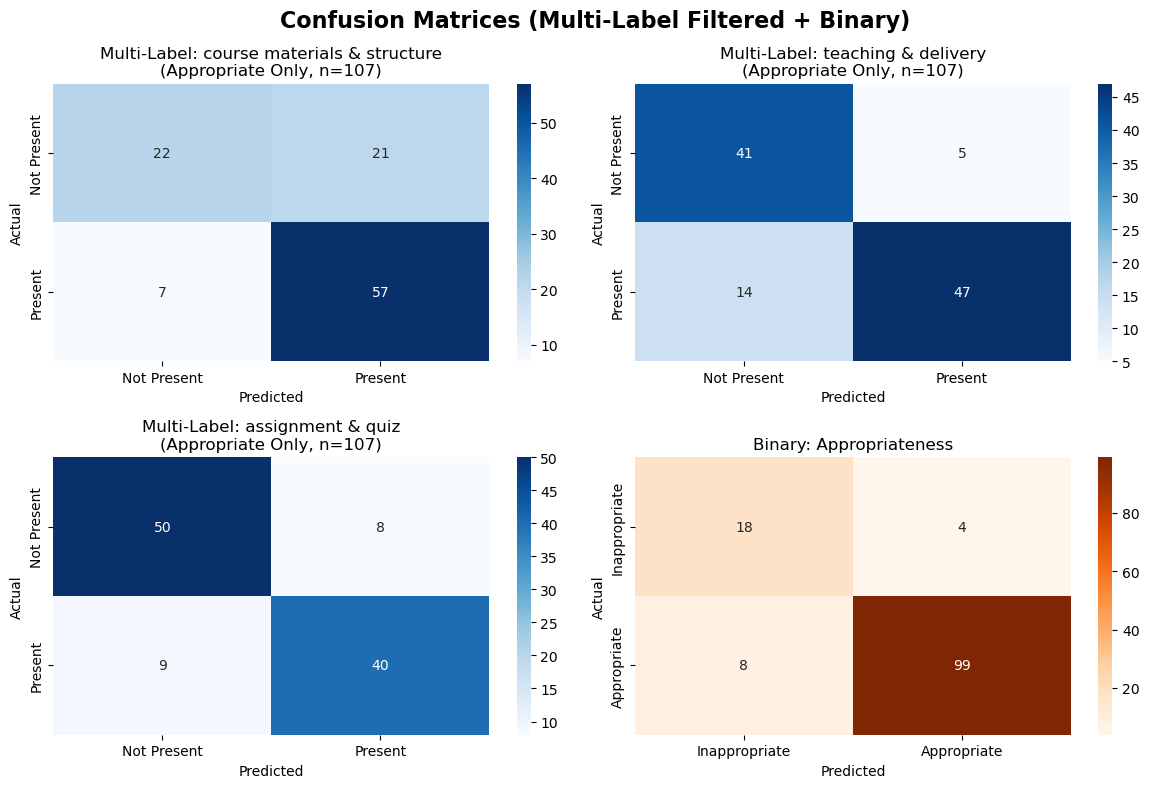

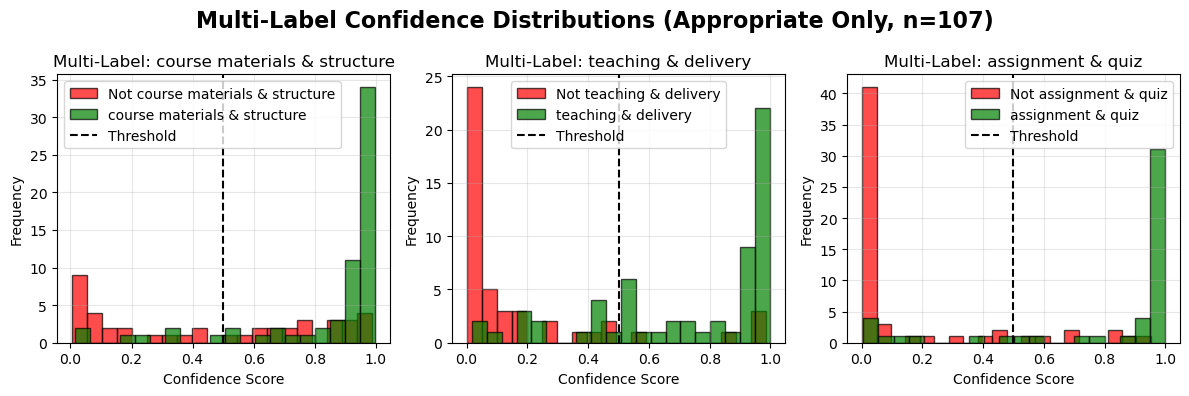

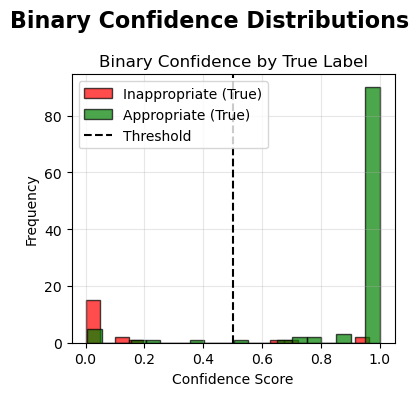


Categorisation Classifier (Appropriate Samples Only, n=107):
                              precision    recall  f1-score   support

course materials & structure     0.7308    0.8906    0.8028        64
         teaching & delivery     0.9038    0.7705    0.8319        61
           assignment & quiz     0.8333    0.8163    0.8247        49

                   micro avg     0.8090    0.8276    0.8182       174
                   macro avg     0.8226    0.8258    0.8198       174
                weighted avg     0.8203    0.8276    0.8192       174
                 samples avg     0.8006    0.8115    0.7850       174


Appropriateness Classifier:
               precision    recall  f1-score   support

Inappropriate     0.6923    0.8182    0.7500        22
  Appropriate     0.9612    0.9252    0.9429       107

     accuracy                         0.9070       129
    macro avg     0.8267    0.8717    0.8464       129
 weighted avg     0.9153    0.9070    0.9100       129



In [33]:
visualize_cascaded_training_results(
    multi_label_model=multi_label_model,
    binary_model=binary_model, 
    dataset=val_dataset,
    training_history_df=None,
    device=device,
    batch_size=8
)

# Testing Model

Here, we test the model using the testing dataset to evaluate its performance on new, unseen data. We begin by loading the pretrained model that was automatically saved during training and then use it to generate labels for the testing set.

In [50]:
import torch
import torch.nn as nn
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

def load_cascaded_models(results_dir="./results_cascaded_multi_label", 
                        model_name="roberta-base",
                        device=None):

    # Check if model files exist
    multi_label_path = os.path.join(results_dir, "best_multilabel_model.pt")
    binary_path = os.path.join(results_dir, "best_binary_model.pt")
    tokenizer_path = os.path.join(results_dir, "tokenizer")
    
    if not os.path.exists(multi_label_path):
        raise FileNotFoundError(f"Multi-label model not found at: {multi_label_path}")
    if not os.path.exists(binary_path):
        raise FileNotFoundError(f"Binary model not found at: {binary_path}")
    
    print(f"Loading models from: {results_dir}")
    print(f"Using device: {device}")

    # Load tokenizer
    if os.path.exists(tokenizer_path):
        print("Loading saved tokenizer")
        try:
            # Try loading with weights_only=False for backward compatibility
            tokenizer = torch.load(tokenizer_path, weights_only=False)
        except Exception as e:
            print(f"Failed to load saved tokenizer ({e}). Loading from HuggingFace instead")
            tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    else:
        print(f"Loading tokenizer from {model_name}")
        tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

    # Initialize multi-label model
    multi_label_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=3,
        problem_type="multi_label_classification"
    )
    
    # Initialize cascaded binary model
    binary_model = CascadedBinaryModel(model_name, num_multilabel_classes=3)
    
    # Load trained weights
    multi_state_dict = torch.load(multi_label_path, map_location="cpu")
    binary_state_dict = torch.load(binary_path, map_location="cpu")

    multi_label_model.load_state_dict(multi_state_dict)
    binary_model.load_state_dict(binary_state_dict)
    
    # Move models to device  
    multi_label_model.to(device)
    binary_model.to(device)

    # Set models to evaluation mode
    multi_label_model.eval()
    binary_model.eval()
    
    print("Models loaded successfully.")
    
    return multi_label_model, binary_model, tokenizer

def predict_with_cascaded_models(multi_label_model, binary_model, tokenizer, 
                                texts, multi_labels=None, binary_labels=None,
                                device=None, batch_size=8, 
                                multi_label_threshold=0.5):

    multi_label_model.eval()
    binary_model.eval()
    
    all_multi_predictions = []
    all_binary_predictions = []
    all_multi_probs = []
    all_binary_probs = []
    all_binary_logits = []
    
    # Process in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt',
            max_length=512
        )
        
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        
        with torch.no_grad():
            # Get multi-label predictions
            multi_outputs = multi_label_model(input_ids=input_ids, attention_mask=attention_mask)
            multi_logits = multi_outputs.logits
            multi_probs = torch.sigmoid(multi_logits)
            multi_preds = (multi_probs > multi_label_threshold).float()
            
            # Get binary predictions using multi-label predictions
            binary_outputs = binary_model(input_ids=input_ids, 
                                        attention_mask=attention_mask, 
                                        multilabel_preds=multi_probs)
            binary_logits = binary_outputs.logits
            binary_probs = torch.sigmoid(binary_logits)
            binary_preds = (binary_probs > 0.5).float()
            
            # Store predictions
            all_multi_predictions.extend(multi_preds.cpu().numpy())
            all_binary_predictions.extend(binary_preds.cpu().numpy())
            all_multi_probs.extend(multi_probs.cpu().numpy())
            all_binary_probs.extend(binary_probs.cpu().numpy())
            all_binary_logits.extend(binary_logits.cpu().numpy())
    
    results = {
        'multi_label_predictions': all_multi_predictions,
        'binary_predictions': all_binary_predictions,
        'multi_label_probabilities': all_multi_probs,
        'binary_probabilities': all_binary_probs,
        'binary_logits': all_binary_logits
    }
    
    # Compute metrics if labels are provided (optional)
    if binary_labels is not None:
        binary_metrics = compute_metrics_binary(
            torch.tensor(np.array(all_binary_logits), dtype=torch.float32),
            torch.tensor(np.array(binary_labels), dtype=torch.float32)
        )

        print(f"Appropriateness Classification Metrics:")
        print(f"Accuracy: {binary_metrics['accuracy']:.4f}")
        print(f"F1: {binary_metrics['f1']:.4f}")
        print(f"Precision: {binary_metrics['precision']:.4f}")
        print(f"Recall: {binary_metrics['recall']:.4f}")

        print(f"Sensitivity (True Positive Rate - Appropriate): {binary_metrics['sensitivity']:.4f}")
        print(f"Specificity (True Negative Rate - Inappropriate): {binary_metrics['specificity']:.4f}")
        
        results['binary_metrics'] = binary_metrics

    if multi_labels is not None and binary_labels is not None:
        
        # Filter to only appropriate samples for multi-label evaluation
        app_mask = np.array(binary_labels) == 1
        
        if app_mask.sum() > 0:
            filtered_multi_probs = np.array(all_multi_probs)
            filtered_multi_labels = np.array(multi_labels)
            
            multi_metrics = compute_metrics_multilabel(
                torch.tensor(filtered_multi_probs, dtype=torch.float32),
                torch.tensor(filtered_multi_labels, dtype=torch.float32),
                tune=True
            )

            print(f"\nCategorisation Classifier:")
            print(f"F1 Micro: {multi_metrics['f1_micro']:.4f}")
            print(f"F1 Macro: {multi_metrics['f1_macro']:.4f}")
            print(f"Subset Accuracy: {multi_metrics['subset_accuracy']:.4f}")
            results['multi_label_metrics'] = multi_metrics
        else:
            print("Categorisation Classifier: No appropriate samples found")
            results['multi_label_metrics'] = None
    
    
    if multi_labels is not None and binary_labels is not None:
        print(f"\nSummary:")
        print(f"Appropriatess F1: {binary_metrics['f1']:.4f}")
        print(f"Categorisation F1 Macro: {multi_metrics['f1_macro']:.4f}")
    
    return results


In [32]:
# Load the pre-trained model
multi_label_model, binary_model, tokenizer = load_cascaded_models(
    results_dir="./results_semi_supervised/iteration_2",
    model_name="roberta-base",
    device=device
)


Loading models from: ./results_semi_supervised/iteration_2
Using device: mps
Loading saved tokenizer


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Models loaded successfully.


In [51]:
# Evaluate the prediction result using new, unseen data
results = predict_with_cascaded_models(
    multi_label_model, binary_model, tokenizer,
    texts=X_test.tolist(),
    multi_labels=y_multi_test,
    binary_labels=y_binary_test,
    device=device
)

Appropriateness Classification Metrics:
Accuracy: 0.8600
F1: 0.9028
Precision: 0.8784
Recall: 0.9286
Sensitivity (True Positive Rate - Appropriate): 0.9286
Specificity (True Negative Rate - Inappropriate): 0.7000

Categorisation Classifier:
F1 Micro: 0.8197
F1 Macro: 0.8173
Subset Accuracy: 0.4900

Summary:
Appropriatess F1: 0.9028
Categorisation F1 Macro: 0.8173
